In [87]:
from pathlib import Path
import urllib.request
import zstandard as zstd
import chess.pgn
import io
import pandas as pd
from tqdm.auto import tqdm

## Define paths and download file

In [88]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

year = 2014
month = 4

filename = f"lichess_db_standard_rated_{year}-{month:02d}.pgn.zst"
url = f"https://database.lichess.org/standard/{filename}"

zst_path = RAW_DIR / filename

print(url)
print(zst_path)

https://database.lichess.org/standard/lichess_db_standard_rated_2014-04.pgn.zst
data/raw/lichess_db_standard_rated_2014-04.pgn.zst


In [89]:
if not zst_path.exists():
  print(f"Downloading {filename}...")
  urllib.request.urlretrieve(url, zst_path)
  print("Done.")
else:
  print("File already exists.")

Done.


## Stream games from compressed ZGN

In [90]:
def iter_pgn_games_from_zst(zst_path, max_games=None):
  """
  Stream games from a .pgn.zst file.

  Yields python-chess Game objects.
  """
  dctx = zstd.ZstdDecompressor()

  with open(zst_path, "rb") as compressed:
    with dctx.stream_reader(compressed) as reader:
      text_stream = io.TextIOWrapper(
        reader,
        encoding="utf-8",
      )

      n_games = 0

      while True:
        game = chess.pgn.read_game(text_stream)

        if game is None:
          break

        yield game

        n_games += 1

        if max_games is not None and n_games >= max_games:
          break

In [91]:
# Inspect the first few games
for i, game in enumerate(
  iter_pgn_games_from_zst(zst_path, max_games=3),
  start=1,
):
  print("=" * 75)
  print(f"GAME {i}")
  print("=" * 75)

  for key, value in game.headers.items():
    print(f"{key}: {value}")

  print()
  print(game)
  print()

GAME 1
Event: Rated Blitz game
Site: https://lichess.org/ijPYwgVx
Date: ????.??.??
Round: ?
White: ljubisa2810
Black: amirmahdi
Result: 1-0
UTCDate: 2014.03.31
UTCTime: 22:01:18
WhiteElo: 1806
BlackElo: 1644
WhiteRatingDiff: +7
BlackRatingDiff: -7
ECO: B40
Opening: Sicilian Defense: Delayed Alapin Variation
TimeControl: 180+0
Termination: Normal

[Event "Rated Blitz game"]
[Site "https://lichess.org/ijPYwgVx"]
[Date "????.??.??"]
[Round "?"]
[White "ljubisa2810"]
[Black "amirmahdi"]
[Result "1-0"]
[UTCDate "2014.03.31"]
[UTCTime "22:01:18"]
[WhiteElo "1806"]
[BlackElo "1644"]
[WhiteRatingDiff "+7"]
[BlackRatingDiff "-7"]
[ECO "B40"]
[Opening "Sicilian Defense: Delayed Alapin Variation"]
[TimeControl "180+0"]
[Termination "Normal"]

1. e4 e6 2. Nf3 c5 3. c3 b6 4. Bb5 Bb7 5. O-O Bxe4 6. d4 Bc6 7. a4 Bxb5 8. axb5 Nf6 9. Re1 cxd4 10. Nxd4 Bc5 11. b4 Bxd4 12. Qxd4 d5 13. Bg5 O-O 14. Nd2 h6 15. Bh4 Nbd7 16. Re3 e5 17. Qd3 g5 18. Rg3 e4 19. Qe3 Kh7 20. Bxg5 hxg5 21. Qxg5 Ng4 22. Rh3+ Nh6 23. 

## Convert game data to records (dictionary object)

In [92]:
def game_to_record(game):
  headers = game.headers

  moves_san = []
  board = game.board()

  for move in game.mainline_moves():
    moves_san.append(board.san(move))
    board.push(move)

  record = {
    "event": headers.get("Event"),
    "site": headers.get("Site"),
    "date": headers.get("UTCDate", headers.get("Date")),
    "time": headers.get("UTCTime"),
    "white": headers.get("White"),
    "black": headers.get("Black"),
    "result": headers.get("Result"),
    "white_elo": headers.get("WhiteElo"),
    "black_elo": headers.get("BlackElo"),
    "white_rating_diff": headers.get("WhiteRatingDiff"),
    "black_rating_diff": headers.get("BlackRatingDiff"),
    "eco": headers.get("ECO"),
    "opening": headers.get("Opening"),
    "time_control": headers.get("TimeControl"),
    "termination": headers.get("Termination"),
    "num_plies": len(moves_san),
    "num_full_moves": len(moves_san) / 2,
    "moves_san": " ".join(moves_san),
  }

  return record

In [94]:
records = []

game_iter = iter_pgn_games_from_zst(
  zst_path,
  max_games=800_000,    # to start, 10.000
)

for game in tqdm(game_iter, total=800_000):
  records.append(game_to_record(game))

df = pd.DataFrame(records)

df.head()

  0%|          | 0/800000 [00:00<?, ?it/s]

,event,site,date,time,white,black,result,white_elo,black_elo,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san
0,Rated Blitz game,https://lichess.org/ijPYwgVx,2014.03.31,22:01:18,ljubisa2810,amirmahdi,1-0,1806,1644,+7,-7,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,22.5,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...
1,Rated Blitz game,https://lichess.org/y5MMbLnm,2014.03.31,22:00:10,Katapult,dododa,1-0,1905,1799,+8,-8,B08,Pirc Defense: Classical Variation,180+0,Normal,61,30.5,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...
2,Rated Blitz game,https://lichess.org/hXbjsQue,2014.03.31,22:00:09,slansson,chycha,1-0,1469,1500,+11,-13,C41,Philidor Defense #3,360+0,Time forfeit,95,47.5,e4 e5 Nf3 d6 Bc4 h6 c3 a6 d4 b5 Bb3 Nf6 dxe5 N...
3,Rated Blitz game,https://lichess.org/kf4hwzAq,2014.03.31,22:00:18,NIS,paiaka,1-0,1131,1063,+9,-11,C41,Philidor Defense #2,300+0,Time forfeit,13,6.5,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3
4,Rated Classical game,https://lichess.org/ZGMLO460,2014.03.31,22:00:33,zinder2,mart1975,1-0,1724,1318,+3,-2,B00,Owen Defense,300+8,Normal,41,20.5,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...


In [95]:
df.shape

(800000, 18)

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   event              800000 non-null  str    
 1   site               800000 non-null  str    
 2   date               800000 non-null  str    
 3   time               800000 non-null  str    
 4   white              800000 non-null  str    
 5   black              800000 non-null  str    
 6   result             800000 non-null  str    
 7   white_elo          800000 non-null  str    
 8   black_elo          800000 non-null  str    
 9   white_rating_diff  789550 non-null  str    
 10  black_rating_diff  789550 non-null  str    
 11  eco                800000 non-null  str    
 12  opening            800000 non-null  str    
 13  time_control       800000 non-null  str    
 14  termination        800000 non-null  str    
 15  num_plies          800000 non-null  int64  
 16  num_full_move

In [97]:
df.head(10)

,event,site,date,time,white,black,result,white_elo,black_elo,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san
0,Rated Blitz game,https://lichess.org/ijPYwgVx,2014.03.31,22:01:18,ljubisa2810,amirmahdi,1-0,1806,1644,+7,-7,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,22.5,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...
1,Rated Blitz game,https://lichess.org/y5MMbLnm,2014.03.31,22:00:10,Katapult,dododa,1-0,1905,1799,+8,-8,B08,Pirc Defense: Classical Variation,180+0,Normal,61,30.5,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...
2,Rated Blitz game,https://lichess.org/hXbjsQue,2014.03.31,22:00:09,slansson,chycha,1-0,1469,1500,+11,-13,C41,Philidor Defense #3,360+0,Time forfeit,95,47.5,e4 e5 Nf3 d6 Bc4 h6 c3 a6 d4 b5 Bb3 Nf6 dxe5 N...
3,Rated Blitz game,https://lichess.org/kf4hwzAq,2014.03.31,22:00:18,NIS,paiaka,1-0,1131,1063,+9,-11,C41,Philidor Defense #2,300+0,Time forfeit,13,6.5,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3
4,Rated Classical game,https://lichess.org/ZGMLO460,2014.03.31,22:00:33,zinder2,mart1975,1-0,1724,1318,+3,-2,B00,Owen Defense,300+8,Normal,41,20.5,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...
5,Rated Bullet game,https://lichess.org/Gc2ly8Ie,2014.03.31,22:00:24,ljubo,RANgO67,0-1,1612,1923,-3,+4,B01,Scandinavian Defense,60+0,Normal,76,38.0,e4 d5 d3 dxe4 dxe4 Qxd1+ Kxd1 c6 Be3 e6 Bd3 f6...
6,Rated Classical game,https://lichess.org/1Tx5l1Ea,2014.03.31,22:00:46,gabrielvictor,Quique75,0-1,1458,1586,-7,+7,B00,Caro-Kann Defense: Hillbilly Attack,420+11,Normal,107,53.5,e4 c6 Bc4 d6 Qf3 Nf6 d3 Bg4 Qg3 e5 Bg5 Nbd7 Nd...
7,Rated Bullet game,https://lichess.org/R66JWTfj,2014.03.31,22:01:12,garciahgv,ispocetka,0-1,1241,1355,-9,+12,A30,English Opening: Symmetrical Variation,60+0,Time forfeit,34,17.0,c4 c5 Nf3 Nc6 e3 Nf6 Be2 d5 cxd5 e6 dxe6 fxe6 ...
8,Rated Bullet game,https://lichess.org/1MSRhANx,2014.03.31,22:00:44,luigi8,bijean,1-0,1467,1151,+3,-4,A46,Yusupov-Rubinstein System,60+1,Time forfeit,29,14.5,d4 e6 Nf3 Nf6 e3 c5 c4 cxd4 exd4 Be7 Nc3 Nc6 B...
9,Rated Bullet game,https://lichess.org/xxTDvHCV,2014.03.31,22:00:23,oxymoron21st,chaian,0-1,1877,1843,-12,+12,C00,French Defense: Normal Variation,60+1,Normal,48,24.0,e4 e6 d4 b6 Bd3 Bb7 Nf3 c5 c3 cxd4 cxd4 Bb4+ N...


In [98]:
cols_to_show = [
  "white_elo",
  "black_elo",
  "result",
  "eco",
  "opening",
  "time_control",
  "termination",
  "num_plies",
]

df[cols_to_show].head(20)

,white_elo,black_elo,result,eco,opening,time_control,termination,num_plies
0,1806,1644,1-0,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45
1,1905,1799,1-0,B08,Pirc Defense: Classical Variation,180+0,Normal,61
2,1469,1500,1-0,C41,Philidor Defense #3,360+0,Time forfeit,95
3,1131,1063,1-0,C41,Philidor Defense #2,300+0,Time forfeit,13
4,1724,1318,1-0,B00,Owen Defense,300+8,Normal,41
5,1612,1923,0-1,B01,Scandinavian Defense,60+0,Normal,76
6,1458,1586,0-1,B00,Caro-Kann Defense: Hillbilly Attack,420+11,Normal,107
7,1241,1355,0-1,A30,English Opening: Symmetrical Variation,60+0,Time forfeit,34
8,1467,1151,1-0,A46,Yusupov-Rubinstein System,60+1,Time forfeit,29
9,1877,1843,0-1,C00,French Defense: Normal Variation,60+1,Normal,48


## Clean data

In [99]:
df["white_elo"] = pd.to_numeric(
  df["white_elo"],
  errors="coerce",
)

df["black_elo"] = pd.to_numeric(
  df["black_elo"],
  errors="coerce",
)

df[["white_elo", "black_elo"]].describe()

,white_elo,black_elo
count,799953.000000,799936.000000
mean,1623.252977,1614.280206
std,224.925099,229.345893
min,757.000000,732.000000
25%,1473.000000,1462.000000
50%,1623.000000,1612.000000
75%,1774.000000,1767.000000
max,2734.000000,2622.000000


In [100]:
# Check for missing values (gives proportion)
df[["white_elo", "black_elo"]].isna().mean()

white_elo    0.000059
black_elo    0.000080
dtype: float64

In [101]:
# Remove invalid data, i.e. missing rating on at least one side
valid_rating_mask = (
  df["white_elo"].notna()
  & df["black_elo"].notna()
)

print("Total games:", len(df))
print("Games with both ratings:", valid_rating_mask.sum())
print("Fraction valid:", valid_rating_mask.mean())

Total games: 800000
Games with both ratings: 799889
Fraction valid: 0.99986125


## Inspect distributions

In [102]:
df_valid = df.loc[valid_rating_mask].copy()

df_valid[
  [
    "white_elo",
    "black_elo",
    "num_plies",
  ]
].describe()

,white_elo,black_elo,num_plies
count,799889.000000,799889.000000,799889.000000
mean,1623.264283,1614.293204,67.556927
std,224.919011,229.337727,32.208265
min,757.000000,732.000000,0.000000
25%,1473.000000,1462.000000,46.000000
50%,1623.000000,1612.000000,64.000000
75%,1774.000000,1767.000000,87.000000
max,2665.000000,2622.000000,344.000000


<Axes: >

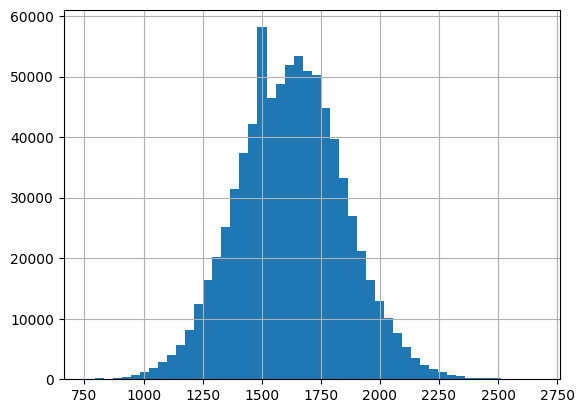

In [103]:
df_valid["white_elo"].hist(bins=50)

<Axes: >

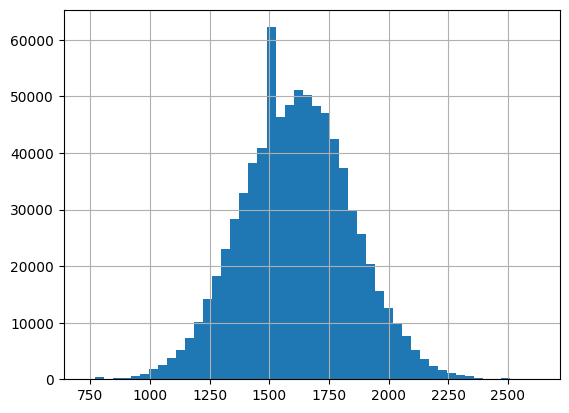

In [104]:
df_valid["black_elo"].hist(bins=50)

<Axes: >

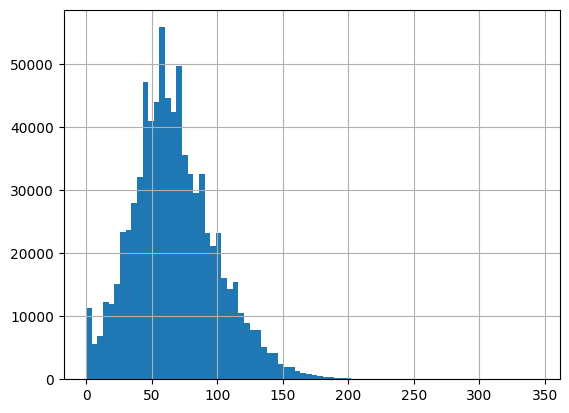

In [105]:
df_valid["num_plies"].hist(bins=80)

In [106]:
df_valid["result"].value_counts(dropna=False)

result
1-0        405104
0-1        367793
1/2-1/2     26992
Name: count, dtype: int64

In [107]:
df_valid["termination"].value_counts(dropna=False).head(20)

termination
Normal              532328
Time forfeit        267484
Rules infraction        77
Name: count, dtype: int64

In [108]:
df_valid["time_control"].value_counts(dropna=False).head(20)

time_control
60+0     105005
300+0     89989
180+0     60352
120+0     51351
300+8     39369
0+1       37450
600+0     29725
240+0     23903
300+5     16116
60+1      15544
420+0     13177
300+3     12418
300+2     12067
900+0     12024
480+0     10938
180+2      9791
360+0      9621
300+1      8993
600+5      7922
600+8      7773
Name: count, dtype: int64

In [109]:
df_valid["eco"].value_counts(dropna=False).head(20)

eco
A00    68875
C00    44279
A40    41776
D00    34660
B01    32615
C20    31419
C41    30790
B00    30546
B20    21144
B07    16501
B06    16440
D02    14886
C40    13367
C23    12044
C50    11868
A01    11109
B10    11006
A04    10830
B21     9898
C44     8964
Name: count, dtype: int64

In [110]:
df_valid["opening"].value_counts(dropna=False).head(20)

opening
Van't Kruijs Opening                             23201
Modern Defense                                   15251
Horwitz Defense                                  14929
Scandinavian Defense: Mieses-Kotroc Variation    13178
Owen Defense                                     12111
French Defense: Knight Variation                 11634
Hungarian Opening                                11573
Caro-Kann Defense                                10887
Sicilian Defense: Bowdler Attack                 10759
Sicilian Defense                                 10729
Scandinavian Defense                             10608
Bishop's Opening                                 10333
Queen's Pawn Game #2                             10288
Philidor Defense #3                              10177
Philidor Defense #2                               8585
Queen's Pawn                                      8440
King's Pawn Game: Leonardis Variation             8244
Queen's Pawn Game: Chigorin Variation             7526
Pi

In [111]:
# Save inspection example
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_save = df_valid.copy()

object_cols = df_save.select_dtypes(include=["object"]).columns

for col in object_cols:
  df_save[col] = df_save[col].astype("string")

sample_name = f"lichess_{year}_{month:02d}_sample_10000.parquet"
sample_path = PROCESSED_DIR / sample_name

df_save.to_parquet(
  sample_path,
  index=False,
  engine="pyarrow",
)

print(f"Wrote: {sample_path}")

/var/folders/n6/ytccpzd10_16pp2m7wyftfnr0000gn/T/ipykernel_2151/1073069695.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_save.select_dtypes(include=["object"]).columns


Wrote: data/processed/lichess_2014_04_sample_10000.parquet


## Reload saved sample (redundant but good infrastructure for later)

In [145]:
df_model = pd.read_parquet(sample_path)

df_model.head()

,event,site,date,time,white,black,result,white_elo,black_elo,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san
0,Rated Blitz game,https://lichess.org/ijPYwgVx,2014.03.31,22:01:18,ljubisa2810,amirmahdi,1-0,1806.0,1644.0,+7,-7,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,22.5,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...
1,Rated Blitz game,https://lichess.org/y5MMbLnm,2014.03.31,22:00:10,Katapult,dododa,1-0,1905.0,1799.0,+8,-8,B08,Pirc Defense: Classical Variation,180+0,Normal,61,30.5,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...
2,Rated Blitz game,https://lichess.org/hXbjsQue,2014.03.31,22:00:09,slansson,chycha,1-0,1469.0,1500.0,+11,-13,C41,Philidor Defense #3,360+0,Time forfeit,95,47.5,e4 e5 Nf3 d6 Bc4 h6 c3 a6 d4 b5 Bb3 Nf6 dxe5 N...
3,Rated Blitz game,https://lichess.org/kf4hwzAq,2014.03.31,22:00:18,NIS,paiaka,1-0,1131.0,1063.0,+9,-11,C41,Philidor Defense #2,300+0,Time forfeit,13,6.5,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3
4,Rated Classical game,https://lichess.org/ZGMLO460,2014.03.31,22:00:33,zinder2,mart1975,1-0,1724.0,1318.0,+3,-2,B00,Owen Defense,300+8,Normal,41,20.5,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...


In [146]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 799889 entries, 0 to 799888
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   event              799889 non-null  string 
 1   site               799889 non-null  string 
 2   date               799889 non-null  string 
 3   time               799889 non-null  string 
 4   white              799889 non-null  string 
 5   black              799889 non-null  string 
 6   result             799889 non-null  string 
 7   white_elo          799889 non-null  float64
 8   black_elo          799889 non-null  float64
 9   white_rating_diff  789550 non-null  string 
 10  black_rating_diff  789550 non-null  string 
 11  eco                799889 non-null  string 
 12  opening            799889 non-null  string 
 13  time_control       799889 non-null  string 
 14  termination        799889 non-null  string 
 15  num_plies          799889 non-null  int64  
 16  num_full_move

In [147]:
df_model[
  [
    "white_elo",
    "black_elo",
    "result",
    "eco",
    "opening",
    "time_control",
    "termination",
    "num_plies",
    "moves_san",
  ]
].head()

,white_elo,black_elo,result,eco,opening,time_control,termination,num_plies,moves_san
0,1806.0,1644.0,1-0,B40,Sicilian Defense: Delayed Alapin Variation,180+0,Normal,45,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...
1,1905.0,1799.0,1-0,B08,Pirc Defense: Classical Variation,180+0,Normal,61,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...
2,1469.0,1500.0,1-0,C41,Philidor Defense #3,360+0,Time forfeit,95,e4 e5 Nf3 d6 Bc4 h6 c3 a6 d4 b5 Bb3 Nf6 dxe5 N...
3,1131.0,1063.0,1-0,C41,Philidor Defense #2,300+0,Time forfeit,13,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3
4,1724.0,1318.0,1-0,B00,Owen Defense,300+8,Normal,41,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...


## Something weird was happening with 1500 ELO

In [148]:
rating_cols = [
  "white_elo",
  "black_elo",
]

df_model[rating_cols].describe()

,white_elo,black_elo
count,799889.000000,799889.000000
mean,1623.264283,1614.293204
std,224.919011,229.337727
min,757.000000,732.000000
25%,1473.000000,1462.000000
50%,1623.000000,1612.000000
75%,1774.000000,1767.000000
max,2665.000000,2622.000000


In [149]:
df_model["white_elo"].value_counts().head(20)

white_elo
1500.0    14576
1662.0     1542
1656.0     1476
1668.0     1464
1614.0     1454
1670.0     1450
1650.0     1448
1649.0     1446
1685.0     1444
1654.0     1443
1682.0     1438
1646.0     1434
1665.0     1432
1652.0     1427
1641.0     1425
1645.0     1424
1615.0     1424
1659.0     1423
1653.0     1422
1627.0     1419
Name: count, dtype: int64

In [150]:
df_model["black_elo"].value_counts().head(20)

black_elo
1500.0    18351
1662.0     1529
1660.0     1414
1638.0     1414
1651.0     1410
1648.0     1409
1632.0     1399
1607.0     1392
1642.0     1390
1658.0     1389
1616.0     1388
1633.0     1387
1626.0     1386
1650.0     1383
1665.0     1380
1672.0     1378
1615.0     1378
1621.0     1374
1653.0     1373
1636.0     1372
Name: count, dtype: int64

In [151]:
white_exact_1500 = df_model["white_elo"].eq(1500)
black_exact_1500 = df_model["black_elo"].eq(1500)

either_exact_1500 = (
  white_exact_1500
  | black_exact_1500
)

print("White exactly 1500:", white_exact_1500.mean())
print("Black exactly 1500:", black_exact_1500.mean())
print("Either exactly 1500:", either_exact_1500.mean())

White exactly 1500: 0.018222528375812144
Black exactly 1500: 0.02294193319323056
Either exactly 1500: 0.04036810107402402


In [152]:
spike_low = 1490
spike_high = 1510

white_near_1500 = df_model["white_elo"].between(
  spike_low,
  spike_high,
)

black_near_1500 = df_model["black_elo"].between(
  spike_low,
  spike_high,
)

either_near_1500 = (
  white_near_1500
  | black_near_1500
)

print("White near 1500:", white_near_1500.mean())
print("Black near 1500:", black_near_1500.mean())
print("Either near 1500:", either_near_1500.mean())

White near 1500: 0.04762535801842506
Black near 1500: 0.05258979683431076
Either near 1500: 0.09589455536955753


<Axes: >

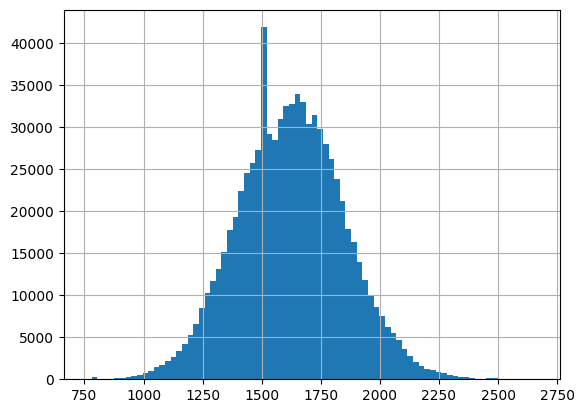

In [153]:
df_model["white_elo"].hist(bins=80)

<Axes: >

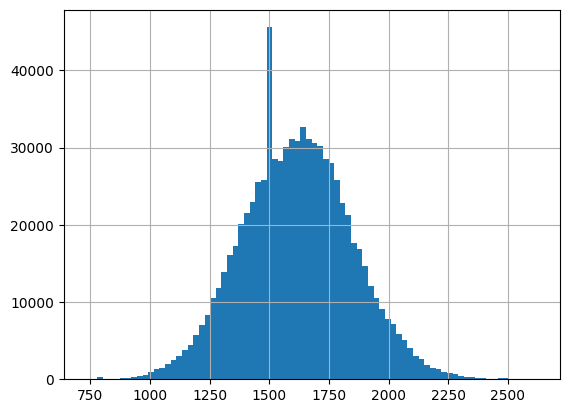

In [154]:
df_model["black_elo"].hist(bins=80)

In [155]:
remove_exact_1500 = True
remove_near_1500 = False

if remove_exact_1500:
  rating_spike_mask = (
    df_model["white_elo"].eq(1500)
    | df_model["black_elo"].eq(1500)
  )

elif remove_near_1500:
  rating_spike_mask = (
    df_model["white_elo"].between(spike_low, spike_high)
    | df_model["black_elo"].between(spike_low, spike_high)
  )

else:
  rating_spike_mask = pd.Series(
    False,
    index=df_model.index,
  )

print("Rows before filtering:", len(df_model))
print("Rows removed:", rating_spike_mask.sum())

df_model = df_model.loc[
  ~rating_spike_mask
].copy()

print("Rows after filtering:", len(df_model))

Rows before filtering: 799889
Rows removed: 32290
Rows after filtering: 767599


<Axes: >

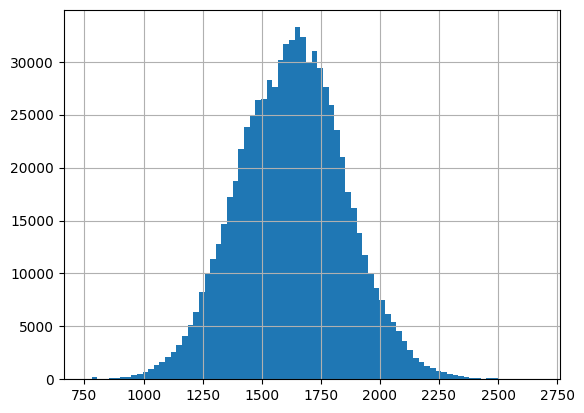

In [156]:
df_model["white_elo"].hist(bins=80)

<Axes: >

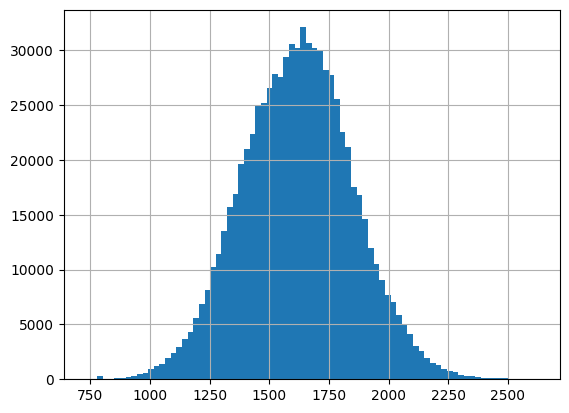

In [157]:
df_model["black_elo"].hist(bins=80)

## Get features that will ultimately be fed to XGBoost
We need to get info about the game from the moves_san column
that we can actually feel to a model. Start with a few basic features that
we can extract.
Number of captures, checks, checkmates, knights moved, etc. See below.

In [115]:
# Conservative start
def add_move_count_features(df):
  df = df.copy()

  moves = df["moves_san"].fillna("")

  df["num_captures"] = moves.str.count("x")
  df["num_checks"] = moves.str.count(r"\+")
  df["num_mates"] = moves.str.count("#")
  df["num_promotions"] = moves.str.count("=")

  df["num_castles_kingside"] = moves.str.count("O-O")
  df["num_castles_queenside"] = moves.str.count("O-O-O")

  df["num_knight_moves"] = moves.str.count(r"\bN")
  df["num_bishop_moves"] = moves.str.count(r"\bB")
  df["num_rook_moves"] = moves.str.count(r"\bR")
  df["num_queen_moves"] = moves.str.count(r"\bQ")
  df["num_king_moves"] = moves.str.count(r"\bK")

  df["capture_frac"] = df["num_captures"] / df["num_plies"]
  df["check_frac"] = df["num_checks"] / df["num_plies"]
  df["promotion_frac"] = df["num_promotions"] / df["num_plies"]

  return df

In [116]:
df_model = add_move_count_features(df_model)

df_model[
  [
    "num_plies",
    "num_captures",
    "num_checks",
    "num_mates",
    "num_promotions",
    "num_castles_kingside",
    "num_castles_queenside",
    "capture_frac",
    "check_frac",
  ]
].describe()

,num_plies,num_captures,num_checks,num_mates,num_promotions,num_castles_kingside,num_castles_queenside,capture_frac,check_frac
count,799889.000000,799889.0,799889.0,799889.0,799889.0,799889.0,799889.0,799812.0,799812.0
mean,67.556927,15.613478,4.801474,0.247131,0.164105,1.486799,0.243736,0.231493,0.063714
std,32.208265,6.976384,4.773921,0.431344,0.468515,0.697414,0.477444,0.06374,0.048441
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,46.000000,11.0,1.0,0.0,0.0,1.0,0.0,0.2,0.027778
50%,64.000000,16.0,4.0,0.0,0.0,2.0,0.0,0.234043,0.056604
75%,87.000000,21.0,7.0,0.0,0.0,2.0,0.0,0.268817,0.091603
max,344.000000,30.0,96.0,1.0,7.0,2.0,2.0,0.625,0.408451


In [158]:
# Split SAN by color
def split_moves_by_color(moves_san):
  if pd.isna(moves_san):
    return [], []

  tokens = str(moves_san).split()

  white_moves = tokens[0::2]
  black_moves = tokens[1::2]

  return white_moves, black_moves

In [159]:
white_black_moves = df_model["moves_san"].apply(
  split_moves_by_color,
)

df_model["white_moves_san"] = white_black_moves.apply(
  lambda x: " ".join(x[0]),
)

df_model["black_moves_san"] = white_black_moves.apply(
  lambda x: " ".join(x[1]),
)

In [160]:
df_model[
  [
    "moves_san",
    "white_moves_san",
    "black_moves_san",
  ]
].head()

,moves_san,white_moves_san,black_moves_san
0,e4 e6 Nf3 c5 c3 b6 Bb5 Bb7 O-O Bxe4 d4 Bc6 a4 ...,e4 Nf3 c3 Bb5 O-O d4 a4 axb5 Re1 Nxd4 b4 Qxd4 ...,e6 c5 b6 Bb7 Bxe4 Bc6 Bxb5 Nf6 cxd4 Bc5 Bxd4 d...
1,e4 d6 Nf3 g6 d4 Bg7 Nc3 Nf6 Bg5 O-O Qe2 Nc6 O-...,e4 Nf3 d4 Nc3 Bg5 Qe2 O-O-O e5 e6 exf7+ Qd2 Bc...,d6 g6 Bg7 Nf6 O-O Nc6 a5 Nd7 Nf6 Rxf7 Bg4 d5 d...
3,e4 e5 Nf3 d6 Nc3 Bg4 Bb5+ c6 Be2 Bxf3 Bxf3 Na6 d3,e4 Nf3 Nc3 Bb5+ Be2 Bxf3 d3,e5 d6 Bg4 c6 Bxf3 Na6
4,e4 b6 d4 Bb7 Nc3 g6 Nf3 Bg7 Bc4 d5 exd5 Nf6 Bb...,e4 d4 Nc3 Nf3 Bc4 exd5 Bb5+ dxc6 Ne5 Nxc6 Ne5+...,b6 Bb7 g6 Bg7 d5 Nf6 c6 Nxc6 a6 Qd6 Kf8 Rd8 Qx...
5,e4 d5 d3 dxe4 dxe4 Qxd1+ Kxd1 c6 Be3 e6 Bd3 f6...,e4 d3 dxe4 Kxd1 Be3 Bd3 Nc3 Nf3 bxc3 Ke2 Bc5 B...,d5 dxe4 Qxd1+ c6 e6 f6 Bb4 Bxc3 Bd7 Ne7 b6 Kxe...


In [161]:
# Add player-separated move count features
def add_color_move_features(df):
  df = df.copy()

  white_moves = df["white_moves_san"].fillna("")
  black_moves = df["black_moves_san"].fillna("")

  df["white_num_moves"] = white_moves.str.split().str.len()
  df["black_num_moves"] = black_moves.str.split().str.len()

  df["white_num_captures"] = white_moves.str.count("x")
  df["black_num_captures"] = black_moves.str.count("x")

  df["white_num_checks"] = white_moves.str.count(r"\+")
  df["black_num_checks"] = black_moves.str.count(r"\+")

  df["white_num_mates"] = white_moves.str.count("#")
  df["black_num_mates"] = black_moves.str.count("#")

  df["white_num_promotions"] = white_moves.str.count("=")
  df["black_num_promotions"] = black_moves.str.count("=")

  df["white_num_castles_king"] = white_moves.str.count("O-O")
  df["black_num_castles_king"] = black_moves.str.count("O-O")

  df["white_num_castles_queen"] = white_moves.str.count("O-O-O")
  df["black_num_castles_queen"] = black_moves.str.count("O-O-O")

  df["white_num_knight_moves"] = white_moves.str.count(r"\bN")
  df["black_num_knight_moves"] = black_moves.str.count(r"\bN")

  df["white_num_bishop_moves"] = white_moves.str.count(r"\bB")
  df["black_num_bishop_moves"] = black_moves.str.count(r"\bB")

  df["white_num_rook_moves"] = white_moves.str.count(r"\bR")
  df["black_num_rook_moves"] = black_moves.str.count(r"\bR")

  df["white_num_queen_moves"] = white_moves.str.count(r"\bQ")
  df["black_num_queen_moves"] = black_moves.str.count(r"\bQ")

  df["white_num_king_moves"] = white_moves.str.count(r"\bK")
  df["black_num_king_moves"] = black_moves.str.count(r"\bK")

  return df

In [162]:
df_model = add_color_move_features(df_model)

In [163]:
# Add fractional versions to make counts more comparable
# across games of different length
for color in ["white", "black"]:
  denom = df_model[f"{color}_num_moves"].replace(0, np.nan)

  df_model[f"{color}_capture_frac"] = (
    df_model[f"{color}_num_captures"] / denom
  )

  df_model[f"{color}_check_frac"] = (
    df_model[f"{color}_num_checks"] / denom
  )

  df_model[f"{color}_promotion_frac"] = (
    df_model[f"{color}_num_promotions"] / denom
  )

In [164]:
color_feature_preview = [
  "white_num_moves",
  "black_num_moves",
  "white_num_captures",
  "black_num_captures",
  "white_num_checks",
  "black_num_checks",
  "white_capture_frac",
  "black_capture_frac",
]

df_model[color_feature_preview].describe()

,white_num_moves,black_num_moves,white_num_captures,black_num_captures,white_num_checks,black_num_checks,white_capture_frac,black_capture_frac
count,767599.000000,767599.000000,767599.000000,767599.000000,767599.000000,767599.000000,767526.000000,767475.000000
mean,34.254065,33.735508,7.864378,7.837312,2.503131,2.321622,0.230302,0.232527
std,16.058296,16.072349,3.654578,3.684710,3.206911,3.102807,0.074998,0.075982
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,23.000000,5.000000,5.000000,0.000000,0.000000,0.189189,0.191781
50%,33.000000,32.000000,8.000000,8.000000,1.000000,1.000000,0.230769,0.232558
75%,44.000000,43.000000,10.000000,10.000000,4.000000,3.000000,0.272727,0.275862
max,172.000000,172.000000,15.000000,15.000000,83.000000,73.000000,0.857143,0.833333


In [165]:
# add opening features
def add_opening_token_features(df, max_plies=20):
  df = df.copy()

  move_lists = df["moves_san"].fillna("").str.split()

  for ply_idx in range(max_plies):
    col_name = f"ply_{ply_idx + 1:02d}"

    df[col_name] = move_lists.apply(
      lambda moves: moves[ply_idx]
      if len(moves) > ply_idx
      else "MISSING"
    )

  return df

In [166]:
max_opening_plies = 20

df_model = add_opening_token_features(
  df_model,
  max_plies=max_opening_plies,
)

In [167]:
# Inspect opening tokens
opening_token_cols = [
  f"ply_{i + 1:02d}"
  for i in range(max_opening_plies)
]

df_model[opening_token_cols].head()

,ply_01,ply_02,ply_03,ply_04,ply_05,ply_06,ply_07,ply_08,ply_09,ply_10,ply_11,ply_12,ply_13,ply_14,ply_15,ply_16,ply_17,ply_18,ply_19,ply_20
0,e4,e6,Nf3,c5,c3,b6,Bb5,Bb7,O-O,Bxe4,d4,Bc6,a4,Bxb5,axb5,Nf6,Re1,cxd4,Nxd4,Bc5
1,e4,d6,Nf3,g6,d4,Bg7,Nc3,Nf6,Bg5,O-O,Qe2,Nc6,O-O-O,a5,e5,Nd7,e6,Nf6,exf7+,Rxf7
3,e4,e5,Nf3,d6,Nc3,Bg4,Bb5+,c6,Be2,Bxf3,Bxf3,Na6,d3,MISSING,MISSING,MISSING,MISSING,MISSING,MISSING,MISSING
4,e4,b6,d4,Bb7,Nc3,g6,Nf3,Bg7,Bc4,d5,exd5,Nf6,Bb5+,c6,dxc6,Nxc6,Ne5,a6,Nxc6,Qd6
5,e4,d5,d3,dxe4,dxe4,Qxd1+,Kxd1,c6,Be3,e6,Bd3,f6,Nc3,Bb4,Nf3,Bxc3,bxc3,Bd7,Ke2,Ne7


In [168]:
# ^ check unique values
for col in opening_token_cols:
  n_unique = df_model[col].nunique(dropna=False)

  print(f"{col}: {n_unique}")

ply_01: 21
ply_02: 21
ply_03: 98
ply_04: 127
ply_05: 319
ply_06: 395
ply_07: 501
ply_08: 563
ply_09: 668
ply_10: 744
ply_11: 825
ply_12: 879
ply_13: 952
ply_14: 995
ply_15: 1080
ply_16: 1114
ply_17: 1224
ply_18: 1235
ply_19: 1346
ply_20: 1351


In [169]:
# One-hot encoding of result feature
def add_result_features(df):
  df = df.copy()

  df["white_won"] = (df["result"] == "1-0").astype(int)
  df["black_won"] = (df["result"] == "0-1").astype(int)
  df["draw"] = (df["result"] == "1/2-1/2").astype(int)

  return df

df_model = add_result_features(df_model)

df_model[
  [
    "result",
    "white_won",
    "black_won",
    "draw",
  ]
].head(10)

,result,white_won,black_won,draw
0,1-0,1,0,0
1,1-0,1,0,0
3,1-0,1,0,0
4,1-0,1,0,0
5,0-1,0,1,0
6,0-1,0,1,0
7,0-1,0,1,0
8,1-0,1,0,0
9,0-1,0,1,0
10,1-0,1,0,0


## Filter games
Remove games with invalid targets, or just very short games.

In [170]:
min_plies = 20    # 2 plies = 1 full turn

model_mask = (
  df_model["white_elo"].notna()
  & df_model["black_elo"].notna()
  & df_model["num_plies"].notna()
  & (df_model["num_plies"] >= min_plies)
)

df_model = df_model.loc[model_mask].copy()

df_model.shape

(729363, 73)

In [171]:
df_model[
  [
    "white_elo",
    "black_elo",
    "num_plies",
  ]
].describe()

,white_elo,black_elo,num_plies
count,729363.000000,729363.000000,729363.000000
mean,1633.651843,1626.098486,71.009792
std,223.606866,227.859893,30.021392
min,760.000000,732.000000,20.000000
25%,1479.000000,1468.000000,49.000000
50%,1636.000000,1628.000000,67.000000
75%,1783.000000,1778.000000,88.000000
max,2665.000000,2622.000000,344.000000


## Select features, create dataset
We will predict two targets:
* `white_elo`
* `black_elo`

For features, we will use numeric move-count features, result flags, game length,
and selected categorical metadata (see below). We will not use features that
could lead to data leakage, such as usernames, rating differences, or site. 

In [172]:
target_cols = [
  "white_elo",
  "black_elo",
]

numeric_features = [
  "num_plies",
  "num_full_moves",
  "white_won",
  "black_won",
  "draw",
  "white_num_moves",
  "black_num_moves",
  "white_num_captures",
  "black_num_captures",
  "white_num_checks",
  "black_num_checks",
  "white_num_mates",
  "black_num_mates",
  "white_num_promotions",
  "black_num_promotions",
  "white_num_castles_king",
  "black_num_castles_king",
  "white_num_castles_queen",
  "black_num_castles_queen",
  "white_num_knight_moves",
  "black_num_knight_moves",
  "white_num_bishop_moves",
  "black_num_bishop_moves",
  "white_num_rook_moves",
  "black_num_rook_moves",
  "white_num_queen_moves",
  "black_num_queen_moves",
  "white_num_king_moves",
  "black_num_king_moves",
  "white_capture_frac",
  "black_capture_frac",
  "white_check_frac",
  "black_check_frac",
  "white_promotion_frac",
  "black_promotion_frac",
]

categorical_features = [
  "result",
  "eco",
  "time_control",
  "termination",
] + opening_token_cols

In [173]:
# Data for XGB
X_raw = df_model[
  numeric_features + categorical_features
].copy()

y = df_model[target_cols].copy()

X_raw.head()

,num_plies,num_full_moves,white_won,black_won,draw,white_num_moves,black_num_moves,white_num_captures,black_num_captures,white_num_checks,...,ply_11,ply_12,ply_13,ply_14,ply_15,ply_16,ply_17,ply_18,ply_19,ply_20
0,45,22.5,1,0,0,23,22,6,5,1,...,d4,Bc6,a4,Bxb5,axb5,Nf6,Re1,cxd4,Nxd4,Bc5
1,61,30.5,1,0,0,31,30,10,9,8,...,Qe2,Nc6,O-O-O,a5,e5,Nd7,e6,Nf6,exf7+,Rxf7
4,41,20.5,1,0,0,21,20,7,6,2,...,exd5,Nf6,Bb5+,c6,dxc6,Nxc6,Ne5,a6,Nxc6,Qd6
5,76,38.0,0,1,0,38,38,10,11,1,...,Bd3,f6,Nc3,Bb4,Nf3,Bxc3,bxc3,Bd7,Ke2,Ne7
6,107,53.5,0,1,0,54,53,9,11,3,...,Bg5,Nbd7,Nd2,Qb6,b3,h6,Bxf6,Nxf6,h3,Bh5


In [174]:
y.head()

,white_elo,black_elo
0,1806.0,1644.0
1,1905.0,1799.0
4,1724.0,1318.0
5,1612.0,1923.0
6,1458.0,1586.0


In [175]:
# Convert non-numerical data to numbers with 1 hot encoding (binary)
X = pd.get_dummies(
  X_raw,
  columns=categorical_features,
  dummy_na=True,
)

X.columns = (
  X.columns
  .astype(str)
  .str.replace("[", "(", regex=False)
  .str.replace("]", ")", regex=False)
  .str.replace("<", "lt", regex=False)
  .str.replace(">", "gt", regex=False)
)

X.head()

,num_plies,num_full_moves,white_won,black_won,draw,white_num_moves,black_num_moves,white_num_captures,black_num_captures,white_num_checks,...,ply_20_hxg1=Q,ply_20_hxg2,ply_20_hxg3,ply_20_hxg3+,ply_20_hxg4,ply_20_hxg4+,ply_20_hxg5,ply_20_hxg5#,ply_20_hxg6,ply_20_nan
0,45,22.5,1,0,0,23,22,6,5,1,...,False,False,False,False,False,False,False,False,False,False
1,61,30.5,1,0,0,31,30,10,9,8,...,False,False,False,False,False,False,False,False,False,False
4,41,20.5,1,0,0,21,20,7,6,2,...,False,False,False,False,False,False,False,False,False,False
5,76,38.0,0,1,0,38,38,10,11,1,...,False,False,False,False,False,False,False,False,False,False
6,107,53.5,0,1,0,54,53,9,11,3,...,False,False,False,False,False,False,False,False,False,False


In [176]:
print("Number of features:", X.shape[1])
print("Number of examples:", X.shape[0])

Number of features: 14803
Number of examples: 729363


## Split data

In [177]:
from sklearn.model_selection import train_test_split

In [178]:
X_train, X_rem, y_train, y_rem = train_test_split(
  X,
  y,
  train_size=0.70,
  random_state=42,
)

X_valid, X_test, y_valid, y_test = train_test_split(
  X_rem,
  y_rem,
  train_size=0.50,
  random_state=42,
)

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (510554, 14803) (510554, 2)
Valid: (109404, 14803) (109404, 2)
Test:  (109405, 14803) (109405, 2)


## Define evaluation helper
We care most about mean absolute error between actual and predicted ratings.

In [179]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

In [180]:
def evaluate_rating_predictions(y_true, y_pred, label):
  white_mae = mean_absolute_error(
    y_true["white_elo"],
    y_pred[:, 0],
  )

  black_mae = mean_absolute_error(
    y_true["black_elo"],
    y_pred[:, 1],
  )

  overall_mae = mean_absolute_error(
    y_true,
    y_pred,
  )

  white_rmse = root_mean_squared_error(
    y_true["white_elo"],
    y_pred[:, 0],
  )

  black_rmse = root_mean_squared_error(
    y_true["black_elo"],
    y_pred[:, 1],
  )

  overall_rmse = root_mean_squared_error(
    y_true,
    y_pred,
  )

  print(label)
  print("-" * len(label))
  print(f"White MAE:    {white_mae:8.2f}")
  print(f"Black MAE:    {black_mae:8.2f}")
  print(f"Overall MAE:  {overall_mae:8.2f}")
  print(f"White RMSE:   {white_rmse:8.2f}")
  print(f"Black RMSE:   {black_rmse:8.2f}")
  print(f"Overall RMSE: {overall_rmse:8.2f}")

## Train a dumb baseline? ChatGPT suggestion?
"Before XGBoost, we need a dumb baseline. If XGBoost cannot beat this, something
is wrong.

This baseline predicts the mean training rating for every game."

### Mean-rating baseline

Before training XGBoost, we create a simple baseline model. This baseline does
not use any chess moves or metadata. It always predicts the average WhiteElo and
average BlackElo from the training set.

This gives us a minimum performance benchmark: if the XGBoost model cannot beat
this baseline on the validation and test sets, then the model is not learning
useful information from the input features.

The code first computes the mean training rating for White and Black, then
duplicates that same two-value prediction for every row in the validation and
test sets. Finally, it evaluates those constant predictions using the same
metrics we will use for the real model.

In [181]:
import numpy as np

In [182]:
mean_prediction = y_train.mean().to_numpy()

valid_baseline_pred = np.tile(
  mean_prediction,
  (len(y_valid), 1),
)

test_baseline_pred = np.tile(
  mean_prediction,
  (len(y_test), 1),
)

evaluate_rating_predictions(
  y_valid,
  valid_baseline_pred,
  "Validation baseline",
)

print()

evaluate_rating_predictions(
  y_test,
  test_baseline_pred,
  "Test baseline",
)

Validation baseline
-------------------
White MAE:      178.31
Black MAE:      182.45
Overall MAE:    180.38
White RMSE:     223.70
Black RMSE:     228.45
Overall RMSE:   226.08

Test baseline
-------------
White MAE:      178.73
Black MAE:      182.41
Overall MAE:    180.57
White RMSE:     223.87
Black RMSE:     228.23
Overall RMSE:   226.05


## XGBoost model

In [183]:
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

In [184]:
base_xgb = XGBRegressor(
  objective="reg:squarederror",
  n_estimators=300,
  max_depth=4,
  learning_rate=0.05,
  subsample=0.9,
  colsample_bytree=0.9,
  reg_lambda=1.0,
  random_state=42,
  n_jobs=-1,
)

model = MultiOutputRegressor(base_xgb)

In [185]:
model.fit(
  X_train,
  y_train,
)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [186]:
valid_pred = model.predict(X_valid)
test_pred = model.predict(X_test)

evaluate_rating_predictions(
  y_valid,
  valid_pred,
  "Validation XGBoost",
)

print()

evaluate_rating_predictions(
  y_test,
  test_pred,
  "Test XGBoost",
)

Validation XGBoost
------------------
White MAE:      148.23
Black MAE:      151.47
Overall MAE:    149.85
White RMSE:     186.97
Black RMSE:     191.01
Overall RMSE:   188.99

Test XGBoost
------------
White MAE:      148.15
Black MAE:      151.47
Overall MAE:    149.81
White RMSE:     187.14
Black RMSE:     190.69
Overall RMSE:   188.92


In [187]:
pred_df = y_test.copy()

pred_df["white_pred"] = np.asarray(test_pred)[:, 0]
pred_df["black_pred"] = np.asarray(test_pred)[:, 1]

pred_df["white_error"] = (
  pred_df["white_pred"] - pred_df["white_elo"]
)

pred_df["black_error"] = (
  pred_df["black_pred"] - pred_df["black_elo"]
)

pred_df.head(20)

,white_elo,black_elo,white_pred,black_pred,white_error,black_error
751811,1698.0,1568.0,1661.717041,1639.845703,-36.282959,71.845703
559261,1648.0,1536.0,1588.682739,1708.880127,-59.317261,172.880127
469000,1681.0,972.0,1647.759155,1498.484009,-33.240845,526.484009
96146,1851.0,1427.0,1608.166626,1437.378052,-242.833374,10.378052
755617,1521.0,1533.0,1645.244507,1640.441040,124.244507,107.441040
566467,1455.0,1350.0,1408.849976,1426.072021,-46.150024,76.072021
650672,1462.0,2077.0,1697.520264,1689.590210,235.520264,-387.409790
87247,1649.0,1699.0,1642.749268,1587.728516,-6.250732,-111.271484
764154,1444.0,1421.0,1523.952637,1612.016846,79.952637,191.016846
146040,1556.0,1372.0,1637.500610,1609.502319,81.500610,237.502319


In [188]:
pred_df[
  [
    "white_error",
    "black_error",
  ]
].describe()

,white_error,black_error
count,109405.000000,109405.000000
mean,-0.312355,0.290733
std,187.139100,190.694893
min,-952.049316,-986.841553
25%,-123.546143,-126.032471
50%,0.051147,1.992432
75%,124.411011,128.717163
max,824.587646,870.027710


## Plot predicted vs true ratings

In [189]:
import matplotlib.pyplot as plt

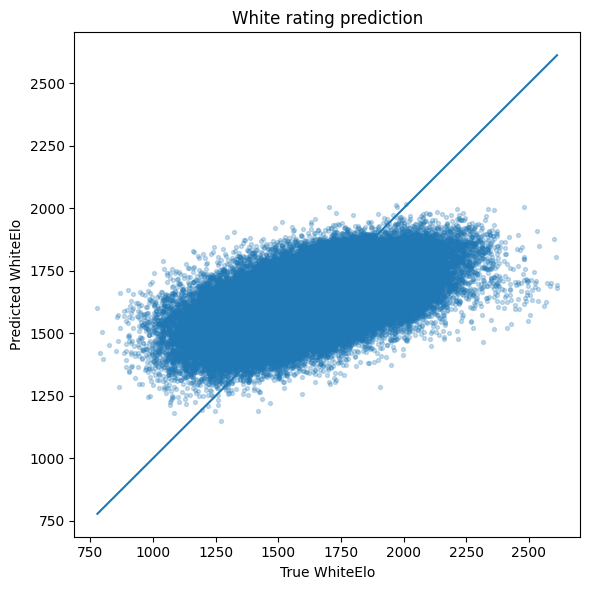

In [190]:
plt.figure(figsize=(6, 6))

plt.scatter(
  pred_df["white_elo"],
  pred_df["white_pred"],
  alpha=0.25,
  s=8,
)

min_rating = min(
  pred_df["white_elo"].min(),
  pred_df["white_pred"].min(),
)

max_rating = max(
  pred_df["white_elo"].max(),
  pred_df["white_pred"].max(),
)

plt.plot(
  [min_rating, max_rating],
  [min_rating, max_rating],
)

plt.xlabel("True WhiteElo")
plt.ylabel("Predicted WhiteElo")
plt.title("White rating prediction")
plt.tight_layout()
plt.show()

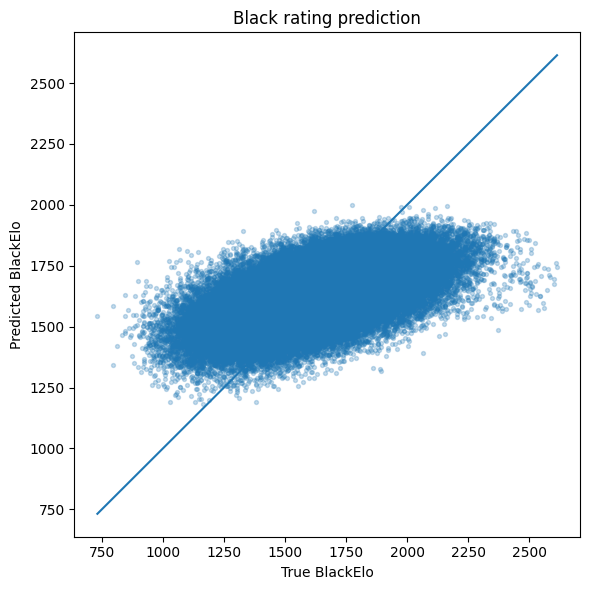

In [191]:
plt.figure(figsize=(6, 6))

plt.scatter(
  pred_df["black_elo"],
  pred_df["black_pred"],
  alpha=0.25,
  s=8,
)

min_rating = min(
  pred_df["black_elo"].min(),
  pred_df["black_pred"].min(),
)

max_rating = max(
  pred_df["black_elo"].max(),
  pred_df["black_pred"].max(),
)

plt.plot(
  [min_rating, max_rating],
  [min_rating, max_rating],
)

plt.xlabel("True BlackElo")
plt.ylabel("Predicted BlackElo")
plt.title("Black rating prediction")
plt.tight_layout()
plt.show()

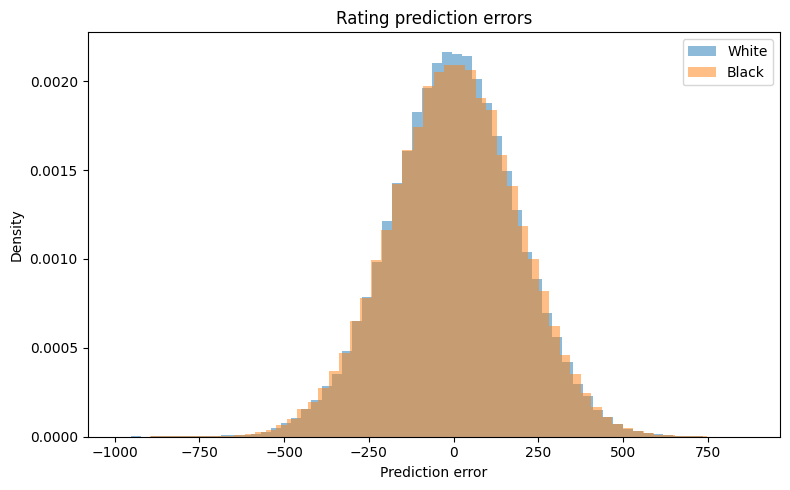

In [192]:
plt.figure(figsize=(8, 5))

plt.hist(
  pred_df["white_error"],
  bins=60,
  alpha=0.5,
  density=True,
  label="White",
)

plt.hist(
  pred_df["black_error"],
  bins=60,
  alpha=0.5,
  density=True,
  label="Black",
)

plt.xlabel("Prediction error")
plt.ylabel("Density")
plt.title("Rating prediction errors")
plt.legend()
plt.tight_layout()
plt.show()

## Inspect feature importance

In [141]:
white_model = model.estimators_[0]
black_model = model.estimators_[1]

importance_df = pd.DataFrame(
  {
    "feature": X_train.columns,
    "white_importance": white_model.feature_importances_,
    "black_importance": black_model.feature_importances_,
  }
)

importance_df["mean_importance"] = (
  importance_df["white_importance"]
  + importance_df["black_importance"]
) / 2

importance_df = importance_df.sort_values(
  "mean_importance",
  ascending=False,
)

importance_df.head(30)

,feature,white_importance,black_importance,mean_importance
662,time_control_180+0,0.067596,0.058984,0.063290
6,num_castles_kingside,0.057859,0.054020,0.055940
917,time_control_60+0,0.040067,0.047556,0.043812
19,result_0-1,0.057301,0.012240,0.034771
16,white_won,0.011091,0.055015,0.033053
20,result_1-0,0.011202,0.049410,0.030306
17,black_won,0.040497,0.007598,0.024048
235,eco_C20,0.021716,0.019731,0.020724
1121,termination_Time forfeit,0.021930,0.017210,0.019570
4,num_mates,0.018526,0.017242,0.017884


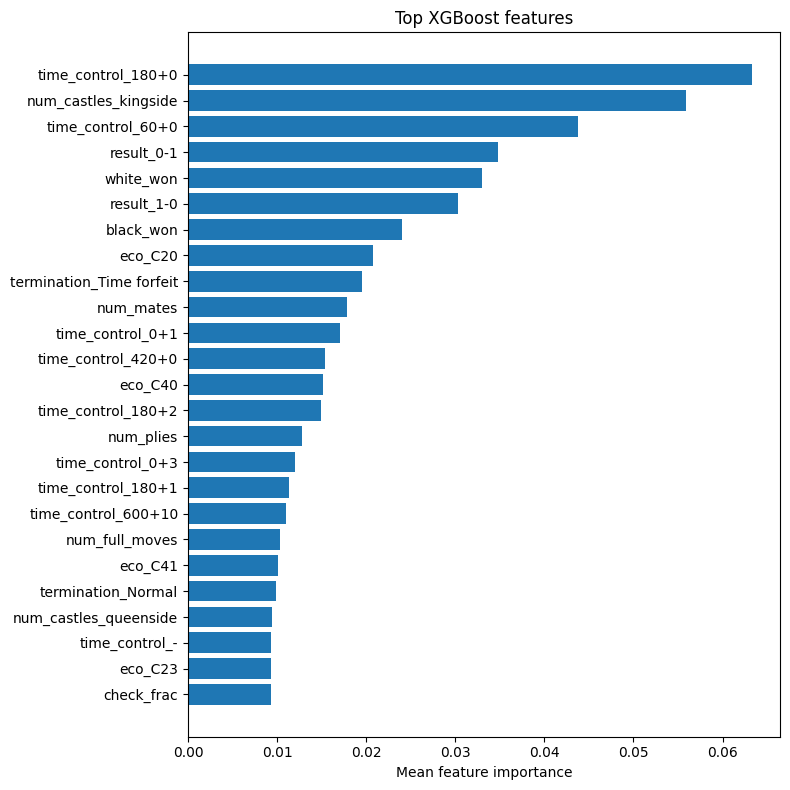

In [142]:
top_importance = importance_df.head(25).copy()

plt.figure(figsize=(8, 8))

plt.barh(
  top_importance["feature"][::-1],
  top_importance["mean_importance"][::-1],
)

plt.xlabel("Mean feature importance")
plt.title("Top XGBoost features")
plt.tight_layout()
plt.show()

In [143]:
import joblib

In [144]:
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "xgb_rating_baseline.joblib"
features_path = MODEL_DIR / "xgb_rating_baseline_features.joblib"

joblib.dump(model, model_path)
joblib.dump(list(X_train.columns), features_path)

print(f"Wrote: {model_path}")
print(f"Wrote: {features_path}")

Wrote: data/models/xgb_rating_baseline.joblib
Wrote: data/models/xgb_rating_baseline_features.joblib
